# Customer Churn Prediction: Telco

**Problem:** Predict which customers are likely to leave, so the retention team can contact them with an offer before they go.

**Data:** 7,043 customers of a telecom company (IBM Telco sample), 19 features: contract, tenure, services, charges, payment method. 26.5% churned.

**Metric:** Average Precision (AP). Churners are the minority, so accuracy would mislead: always predicting "stays" is 73.5% accurate and catches nobody.

**Result:** Logistic regression ranks churners well (test AP 0.634 vs 0.265 for random). With a cost-based threshold of 0.21 instead of the default 0.5, it catches 85% of churners instead of 56%, and total cost on the test set falls from $114k to $95k (about 17%) under assumed costs of $100 per offer and $500 per lost customer.

In [1]:
# Imports and data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, confusion_matrix
from xgboost import XGBClassifier

# one row per customer; data file not included in the repo (see README)
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
print(df.shape)

(7043, 21)


## 1. Data fixes

TotalCharges is stored as text because 11 values are blank. All 11 belong to customers with tenure 0 (new, not billed yet), so the true total is 0, not a missing value.

In [2]:
# blank TotalCharges = new customers not billed yet, so their total so far is 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

# target as 1/0; customerID is only a label, so it's dropped with the target
y = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["customerID", "Churn"])
churned = y == 1

print(X.shape, "| churn rate:", round(y.mean(), 3))

(7043, 19) | churn rate: 0.265


## 2. Who churns

About 1 in 4 customers left (26.5%). The risk is concentrated in new customers and month-to-month contracts.

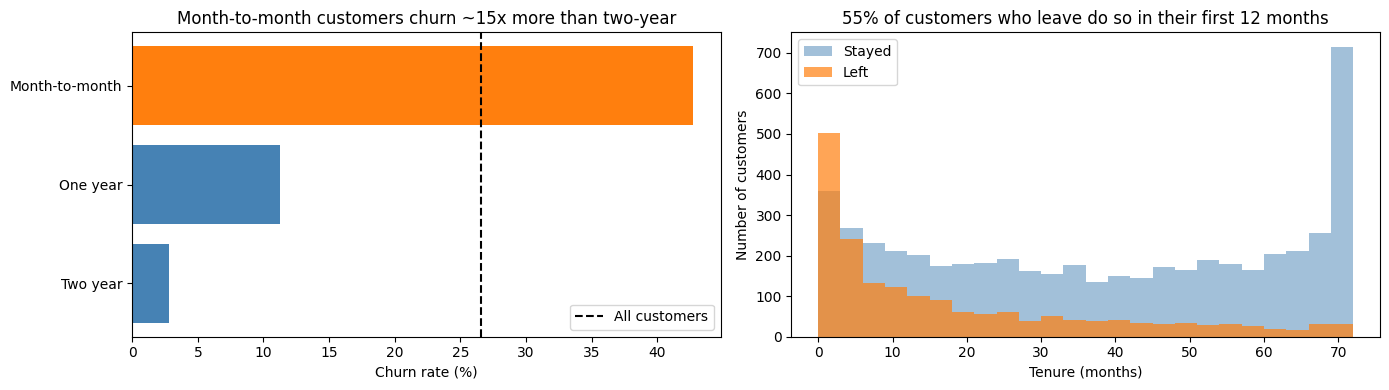

In [4]:
# Contract and tenure, side by side

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
avg = churned.mean() * 100

# left: churn rate by contract; orange = highest-risk group
rate = churned.groupby(df["Contract"]).mean().sort_values() * 100
ax[0].barh(rate.index, rate.values, color=["tab:orange" if v == rate.max() else "steelblue" for v in rate.values])
ax[0].axvline(avg, color="black", linestyle="--", label="All customers")
ax[0].set_title("Month-to-month customers churn ~15x more than two-year")
ax[0].set_xlabel("Churn rate (%)")
ax[0].legend(loc="lower right")

# right: tenure of customers who left vs stayed, same bins for both groups
bins = range(0, 75, 3)
ax[1].hist(df.loc[~churned, "tenure"], bins=bins, alpha=0.5, color="steelblue", label="Stayed")
ax[1].hist(df.loc[churned, "tenure"], bins=bins, alpha=0.7, color="tab:orange", label="Left")
ax[1].set_title("55% of customers who leave do so in their first 12 months")
ax[1].set_xlabel("Tenure (months)")
ax[1].set_ylabel("Number of customers")
ax[1].legend()

plt.tight_layout()
plt.show()

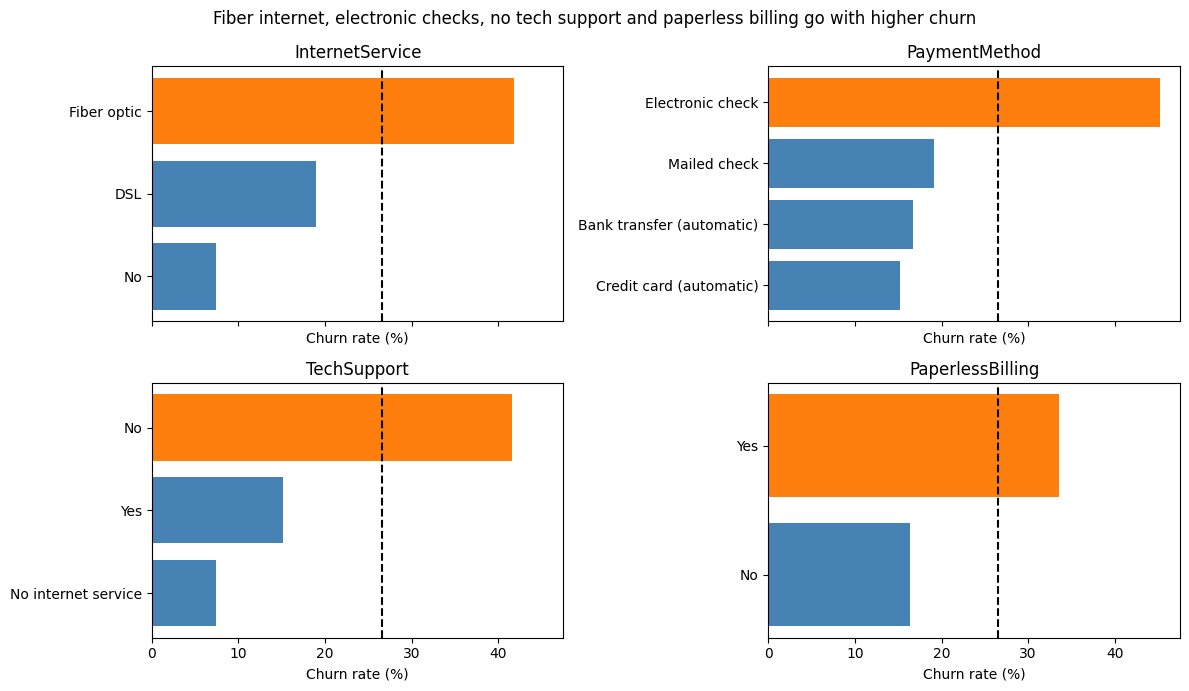

In [5]:
# Services and payment

cols = ["InternetService", "PaymentMethod", "TechSupport", "PaperlessBilling"]

# sharex=True: all 4 panels use the same scale, so bar lengths compare fairly
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for col, ax in zip(cols, axes.flat):
    # churn rate per group; orange = above the overall average
    rate = churned.groupby(df[col]).mean().sort_values() * 100
    ax.barh(rate.index, rate.values, color=["tab:orange" if v > avg else "steelblue" for v in rate.values])
    ax.axvline(avg, color="black", linestyle="--")
    ax.set_title(col)
    ax.set_xlabel("Churn rate (%)")

fig.suptitle("Fiber internet, electronic checks, no tech support and paperless billing go with higher churn")
plt.tight_layout()
plt.show()

**What I see**
- Month-to-month customers churn at ~43% vs ~3% for two-year contracts; 55% of churners leave within their first year.
- Fiber optic (~42%), electronic check (~45%), no tech support (~42%) and paperless billing (~34%) all churn above the 26.5% average.
- Customers paying more per month churn more (median ~$80 vs ~$64), mostly because fiber is the expensive plan.
- These are correlations, not causes: month-to-month and fiber customers may differ in other ways.

## 3. Split and pipeline

20% of customers are held out for the final check. The split is stratified so both sets keep the 26.5% churn rate. Numbers are scaled (KNN, SVM and MLP use distances or gradients) and text columns are one-hot encoded. There are no gaps left, so no imputer is needed.

In [7]:

# stratify=y keeps 26.5% churners in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

num_cols = X_train.select_dtypes("number").columns
cat_cols = X_train.select_dtypes("object").columns
prep = make_column_transformer((StandardScaler(), num_cols),
                               (OneHotEncoder(handle_unknown="ignore"), cat_cols))

print(X_train.shape, X_test.shape, "| churn rate train/test:", round(y_train.mean(), 3), round(y_test.mean(), 3))

(5634, 19) (1409, 19) | churn rate train/test: 0.265 0.265


## 4. Model comparison

Every model uses the same pipeline, the same 5 stratified folds and the same metric (Average Precision). A model that gives everyone the same score gets AP 0.265, the churn rate.

In [8]:
models = {
    "Baseline": DummyClassifier(strategy="prior"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree (depth 5)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                             subsample=0.8, colsample_bytree=0.8, random_state=42),
    "KNN (k=50)": KNeighborsClassifier(n_neighbors=50),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0),
    "MLP (32, 16)": MLPClassifier(hidden_layer_sizes=(32, 16), alpha=1e-3, max_iter=500,
                                  early_stopping=True, random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(make_pipeline(prep, model), X_train, y_train, cv=5, scoring="average_precision")
    results[name] = scores.mean()
    print(f"{name}: AP {scores.mean():.3f} (+/- {scores.std():.3f})")

Baseline: AP 0.265 (+/- 0.000)
Logistic Regression: AP 0.662 (+/- 0.028)
Decision Tree (depth 5): AP 0.600 (+/- 0.028)
Random Forest: AP 0.663 (+/- 0.032)
XGBoost: AP 0.667 (+/- 0.030)
KNN (k=50): AP 0.624 (+/- 0.028)
SVM (RBF): AP 0.644 (+/- 0.027)
MLP (32, 16): AP 0.651 (+/- 0.029)


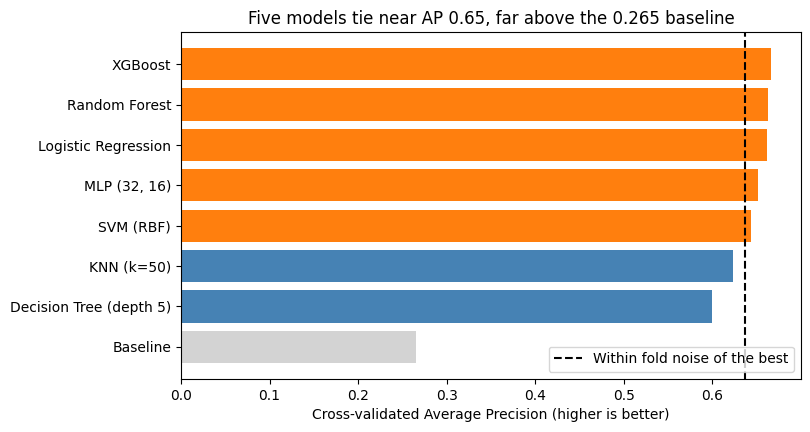

In [9]:
# Chart of the comparison


res = pd.Series(results).sort_values()
best = res.max()

# orange = within fold noise (~0.03) of the best, so tied with it; grey = baseline
colors = ["lightgrey" if k == "Baseline" else "tab:orange" if v >= best - 0.03 else "steelblue"
          for k, v in res.items()]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(res.index, res.values, color=colors)
ax.axvline(best - 0.03, color="black", linestyle="--", label="Within fold noise of the best")
ax.set_title("Five models tie near AP 0.65, far above the 0.265 baseline")
ax.set_xlabel("Cross-validated Average Precision (higher is better)")
ax.legend(loc="lower right")
plt.show()

**Model choice:** XGBoost (0.667), Random Forest (0.663), Logistic Regression (0.662), MLP (0.651) and SVM (0.644) all sit within the ~0.03 fold-to-fold noise, so they are tied. When very different methods reach the same level, the data sets the ceiling, not the algorithm.

I choose **Logistic Regression**: same accuracy, fastest to train and serve, gives real probabilities, and its coefficients show why a customer is flagged, which matters to a retention team. This was decided before touching the test set.

Overfitting lessons from exploration: an unlimited decision tree scored AP 0.360 (it memorized the training data), and KNN with k=5 scored 0.508 (too few neighbours give coarse, noisy scores).

## 5. Final model and test result

Tuning C (the inverse of the penalty strength) with 5-fold CV, then one look at the 1,409 held-out customers.

In [13]:
# Tune, then test once

# C from 0.01 (strong penalty) to 10 (weak penalty), scored on training folds only
lr_grid = GridSearchCV(make_pipeline(prep, LogisticRegression(max_iter=1000)),
                       {"logisticregression__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]},
                       cv=5, scoring="average_precision")
lr_grid.fit(X_train, y_train)
final_model = lr_grid.best_estimator_
print("Best C:", lr_grid.best_params_["logisticregression__C"], "| CV AP:", round(lr_grid.best_score_, 3))

# the one and only use of the test set
proba_test = final_model.predict_proba(X_test)[:, 1]
print("Test AP:", round(average_precision_score(y_test, proba_test), 3),
      "| Test ROC AUC:", round(roc_auc_score(y_test, proba_test), 3))

Best C: 1 | CV AP: 0.662
Test AP: 0.634 | Test ROC AUC: 0.842


**What I see**
- Tuning picked C=1 (the default), so the default penalty was already right.
- Test AP 0.634 vs CV 0.662: about one fold-std lower, normal variation for ~373 test churners.
- ROC AUC 0.842 looks stronger than AP because it also rewards ranking the many stayers; AP is the honest view of the call list.

## 6. Choosing the threshold

The model outputs a probability; the business needs a yes/no: call this customer or not? The default threshold 0.5 has no business meaning, so the threshold is chosen by cost.

**Assumed costs** (placeholders; the real numbers would come from the business):
- Every flagged customer gets a retention offer: $100.
- A churner who isn't flagged leaves: $500 of lost revenue.
- The offer always keeps the customer (simplistic).

The threshold is chosen on out-of-fold predictions from the training set, so the test set plays no part in the choice.

In [14]:
# Find the cheapest threshold


offer_cost, lost_cost = 100, 500   # assumed, see above

# each training customer gets a probability from a model that never saw them
proba_oof = cross_val_predict(final_model, X_train, y_train, cv=5, method="predict_proba")[:, 1]

# total cost at every threshold = offers sent + churners missed
grid = np.arange(0.05, 0.95, 0.01)
costs = np.array([(proba_oof >= t).sum() * offer_cost
                  + ((proba_oof < t) & (y_train.values == 1)).sum() * lost_cost for t in grid])
best_t = round(float(grid[costs.argmin()]), 2)
print("Cheapest threshold:", best_t, "| theory: 100 / 500 =", 100 / 500)

Cheapest threshold: 0.21 | theory: 100 / 500 = 0.2


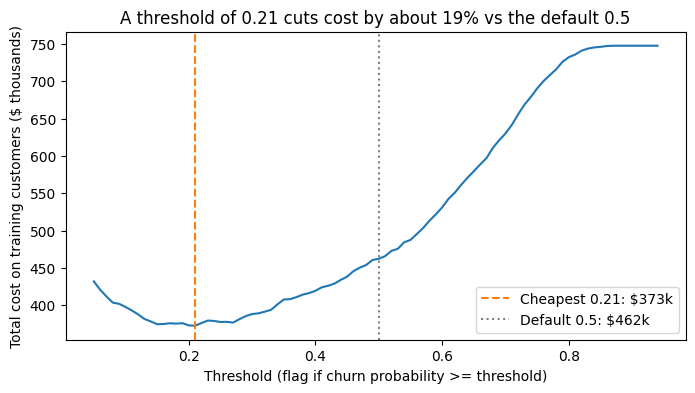

In [16]:
# Cost curve
cost_05 = costs[np.argmin(np.abs(grid - 0.5))]   # cost at the default threshold

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grid, costs / 1000)
ax.axvline(best_t, color="tab:orange", linestyle="--", label=f"Cheapest {best_t:.2f}: ${costs.min()/1000:.0f}k")
ax.axvline(0.5, color="grey", linestyle=":", label=f"Default 0.5: ${cost_05/1000:.0f}k")
ax.set_title("A threshold of 0.21 cuts cost by about 19% vs the default 0.5")
ax.set_xlabel("Threshold (flag if churn probability >= threshold)")
ax.set_ylabel("Total cost on training customers ($ thousands)")
ax.legend()
plt.show()

In [17]:
# Apply to the test set

# compare the chosen threshold with the default on unseen customers
for t in [best_t, 0.5]:
    tn, fp, fn, tp = confusion_matrix(y_test, (proba_test >= t).astype(int)).ravel()
    cost = (tp + fp) * offer_cost + fn * lost_cost
    print(f"Threshold {t:.2f}: caught {tp}, missed {fn}, wasted offers {fp} | "
          f"precision {tp/(tp+fp):.0%}, recall {tp/(tp+fn):.0%} | cost ${cost/1000:.0f}k")

Threshold 0.21: caught 317, missed 57, wasted offers 352 | precision 47%, recall 85% | cost $95k
Threshold 0.50: caught 209, missed 165, wasted offers 109 | precision 66%, recall 56% | cost $114k


**What I see**
- The cheapest threshold (0.21) matches the theory: flag when probability x $500 > $100, i.e. above 0.20. It works because the probabilities are well calibrated.
- The cost curve is flat between ~0.15 and ~0.27, so the choice is robust to small changes in the assumed costs.
- On the test set, 0.21 catches 85% of churners (vs 56% at 0.5) and costs $95k vs $114k, about 17% less, in line with the ~19% on training data.
- Key caveat: if only half of offers keep the customer, the best threshold rises to ~0.40. The offer's real success rate is the first thing to ask the business.

## 7. What drives churn

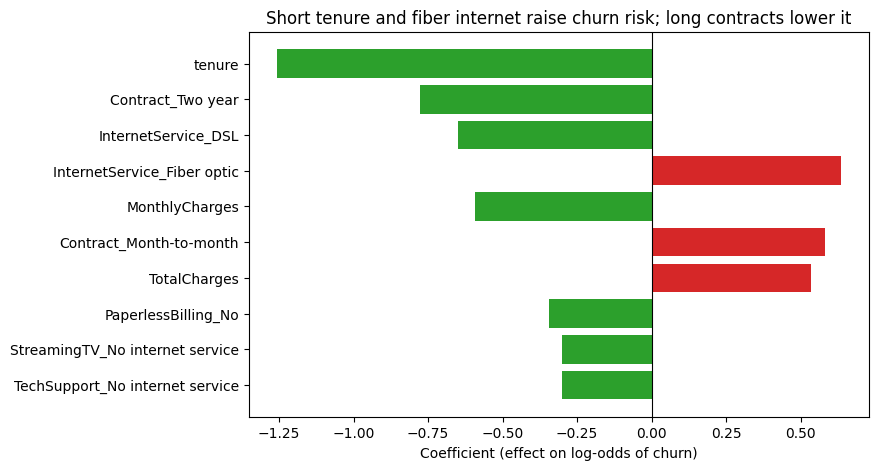

In [18]:
# Top 10 coefficients


# one coefficient per model input; positive = raises churn risk, negative = lowers it
coefs = pd.Series(final_model[-1].coef_[0], index=final_model[0].get_feature_names_out())
coefs.index = coefs.index.str.split("__").str[1]

# 10 biggest effects by size; red raises churn, green lowers it
top = coefs[coefs.abs().sort_values().index].tail(10)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=["tab:red" if v > 0 else "tab:green" for v in top.values])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Short tenure and fiber internet raise churn risk; long contracts lower it")
ax.set_xlabel("Coefficient (effect on log-odds of churn)")
plt.show()

**Reading the coefficients** (log-odds; e^coefficient = change in the odds of churning):
- Tenure has the biggest effect: about 2 more years (1 std) cuts the odds of churning to ~29%.
- Fiber optic (~1.9x the odds) and month-to-month contracts raise risk; two-year contracts and DSL lower it.
- MonthlyCharges is negative even though churners pay more: fiber, the expensive plan, already carries that effect. A coefficient's meaning depends on the other features in the model.
- TotalCharges (+) and tenure (-) are strongly correlated (0.83), so the model splits their effect; neither can be read alone.

## 8. Next steps

- **Real costs:** get the actual offer cost, the value of a kept customer, and the offer's success rate from the business; the threshold depends heavily on them.
- **Better features:** five very different models tied, so new information (support calls, usage trends, complaints) would help more than a new algorithm.
- **Explanations per customer:** SHAP values would show why each individual customer is flagged.
- **Deployment:** serve the model through an API, and monitor whether the churn rate and feature patterns drift over time.